In [1]:
import pandas as pd 
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
def merge_dfs(dfs:list):
    for i in range(len(dfs)):
        if i==0:
            df=dfs[i]
        else:
            df = pd.merge(df, dfs[i], left_index=True, right_index=True)
    return df

def clean_process(df):
    df=df.where(df!=0,np.nan)                               # - Replace 0 with NaNs
    df=df.dropna()                                          # - Drop NaNs (preliminarily)
    df=df.resample('D', kind='timestamp', ).asfreq()        # - Make sure time axis is even
    df=df.interpolate('linear')                             # - Fill resulting NaNs with linear interpolation
    return df

# Load, Process, Align Dates

In [42]:
folder=r'/Users/igorbykov/Desktop/Thesis/data'

# Get Brent data
name=r'commodities_data_v0.xlsx'
brent = pd.read_excel(
    os.path.join(folder,name),
    usecols=[0,1],
    index_col=0
    )
brent.index = pd.to_datetime(brent.index) # - TTF Nat Gas Spot; USD (assumed)
brent = clean_process(brent)

# Get TTF data - EUR
name=r'ttf_front_month.xlsx'
ttf = pd.read_excel(
    os.path.join(folder,name),
    usecols=[0,1],
    index_col=0
    )
ttf.index = pd.to_datetime(ttf.index) # - TTF Nat Gas Spot; USD (assumed)
ttf = clean_process(ttf)

# Utility debt yield index data (10Y)
name=r'utilities_debt.xlsx'
util_yield_10y=pd.read_excel(
    os.path.join(folder,name),
    usecols=[0,3],
    index_col=0
    )/100                                                       # - Convert from percentage points to decimals  
util_yield_10y.index = pd.to_datetime(util_yield_10y.index)     # - Ensure datatime indexation
util_yield_10y = clean_process(util_yield_10y)

# Get EUR curve data (10Y)
name=r'euro_curve.xlsx'
govt_yield_10y=pd.read_excel(
    os.path.join(folder,name),
    usecols=[0,2],
    index_col=0
    )/100                                                       # - Convert from percentage points to decimals
govt_yield_10y.index = pd.to_datetime(govt_yield_10y.index)     # - Ensure datatime indexation
govt_yield_10y = clean_process(govt_yield_10y)

/var/folders/4_/ym5ph8gd12lfqnhrxz6p53rw0000gn/T/ipykernel_26418/4113266116.py:12: FutureWarning: The 'kind' keyword in DataFrame.resample is deprecated and will be removed in a future version. Explicitly cast the index to the desired type instead
  df=df.resample('D', kind='timestamp', ).asfreq()        # - Make sure time axis is even
/var/folders/4_/ym5ph8gd12lfqnhrxz6p53rw0000gn/T/ipykernel_26418/4113266116.py:12: FutureWarning: The 'kind' keyword in DataFrame.resample is deprecated and will be removed in a future version. Explicitly cast the index to the desired type instead
  df=df.resample('D', kind='timestamp', ).asfreq()        # - Make sure time axis is even
/var/folders/4_/ym5ph8gd12lfqnhrxz6p53rw0000gn/T/ipykernel_26418/4113266116.py:12: FutureWarning: The 'kind' keyword in DataFrame.resample is deprecated and will be removed in a future version. Explicitly cast the index to the desired type instead
  df=df.resample('D', kind='timestamp', ).asfreq()        # - Make sure time

# Duration Assumptions, Convert to Log-Returns, Combine

In [73]:
# Convert util yields to returns
# Utility duration will be higher than Govt duration 

D_util = 7.5
D_govt = 8.5

R_util = np.log((1-D_util * util_yield_10y.diff()).dropna() )
R_govt = np.log((1-D_govt * govt_yield_10y.diff()).dropna() )

R_brent = np.log((1+brent.diff() / brent.shift(1)).dropna() )
R_ttf = np.log((1+ttf.diff() / ttf.shift(1)).dropna() )

df = merge_dfs([R_brent, R_ttf, R_util, R_govt]).dropna()

# Resample frequency
df = df.resample('30D').last()

print(df.head(5))

            CO1 Comdty  TTF_front_month  IGEEUA10 BVLI Index       10Y
2011-04-30   -0.001016         0.000826            -0.000073  0.000582
2011-05-30    0.025983        -0.002057            -0.004390 -0.000252
2011-06-29   -0.000596        -0.000161            -0.000045  0.000823
2011-07-29    0.001555         0.005316            -0.002185  0.000824
2011-08-28   -0.000096        -0.000184             0.001259  0.000544


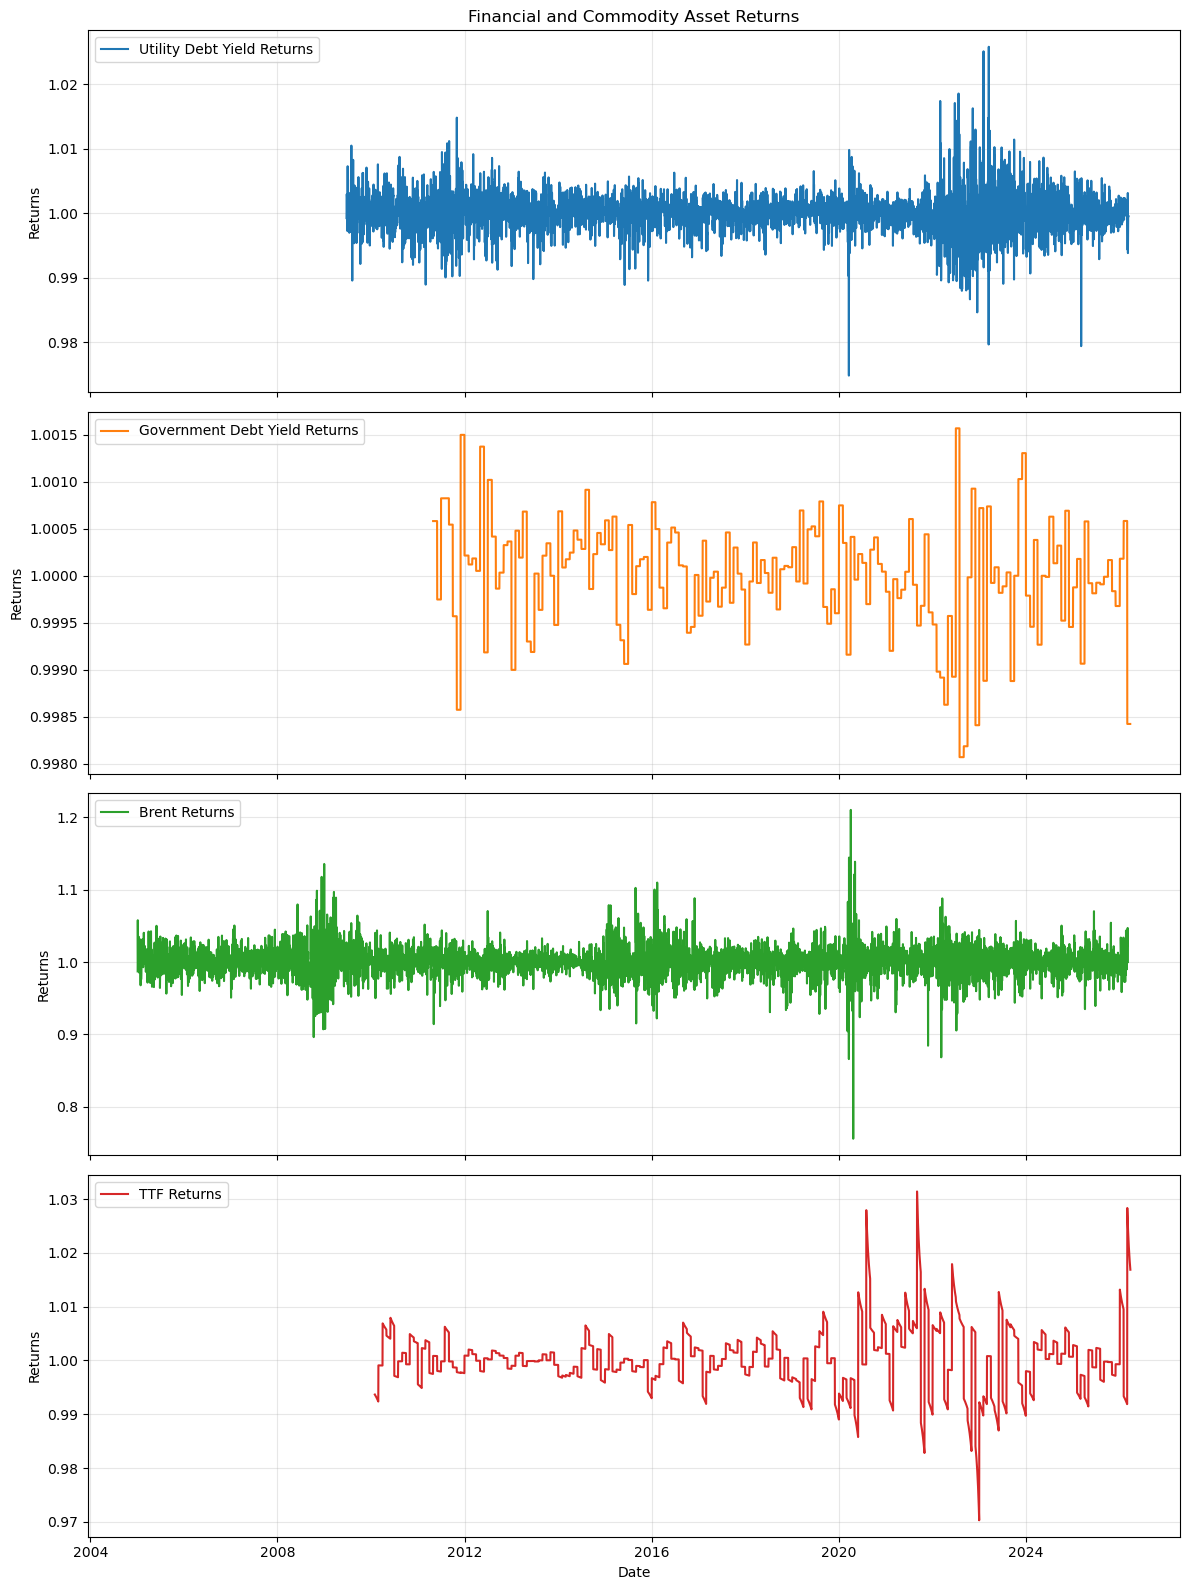

In [74]:
series_to_plot = {
    'Utility Debt Yield Returns': (1 - D_util * util_yield_10y.diff()).dropna(),
    'Government Debt Yield Returns': (1 - D_govt * govt_yield_10y.diff()).dropna(),
    'Brent Returns': (1 + brent.pct_change()).dropna(),
    'TTF Returns': (1 + ttf.pct_change()).dropna()
}

fig, axes = plt.subplots(nrows=4, ncols=1, figsize=(12, 16), sharex=True)

for i, (label, data) in enumerate(series_to_plot.items()):
    axes[i].plot(data, label=label, color=f'C{i}') # C0, C1, etc. gives distinct colors
    axes[i].set_ylabel('Returns')
    axes[i].legend(loc='upper left')
    axes[i].grid(True, alpha=0.3)

axes[0].set_title('Financial and Commodity Asset Returns')
plt.xlabel('Date')
plt.tight_layout() # Prevents labels from overlapping
plt.show()

# Baseline Unconditional Hedge Model

In [86]:
df['excess_R_util'] = df['IGEEUA10 BVLI Index'] - df['10Y']

# target = ['IGEEUA10 BVLI Index']
target = ['excess_R_util']

In [87]:
unconditional_model_brent = sm.OLS(
    df[target],
    sm.add_constant(
        df[['10Y','CO1 Comdty']]
        ), 
        cov_type='HC3'
        ).fit()

print(unconditional_model_brent.summary())

                            OLS Regression Results                            
Dep. Variable:          excess_R_util   R-squared:                       0.037
Model:                            OLS   Adj. R-squared:                  0.026
Method:                 Least Squares   F-statistic:                     3.400
Date:                Wed, 25 Mar 2026   Prob (F-statistic):             0.0356
Time:                        16:13:56   Log-Likelihood:                 843.88
No. Observations:                 181   AIC:                            -1682.
Df Residuals:                     178   BIC:                            -1672.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       8.896e-05      0.000      0.519      0.6

/Users/igorbykov/opt/anaconda3/envs/quant/lib/python3.14/site-packages/statsmodels/base/model.py:130: ValueWarning: unknown kwargs ['cov_type']
  warnings.warn(msg, ValueWarning)


In [88]:
unconditional_model_ttf = sm.OLS(
    df[target],
    sm.add_constant(
        df[['10Y','TTF_front_month']]
        ), 
        cov_type='HC3'
        ).fit()
print(unconditional_model_ttf.summary())

                            OLS Regression Results                            
Dep. Variable:          excess_R_util   R-squared:                       0.073
Model:                            OLS   Adj. R-squared:                  0.062
Method:                 Least Squares   F-statistic:                     6.999
Date:                Wed, 25 Mar 2026   Prob (F-statistic):            0.00119
Time:                        16:13:56   Log-Likelihood:                 847.33
No. Observations:                 181   AIC:                            -1689.
Df Residuals:                     178   BIC:                            -1679.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const            8.092e-05      0.000     

/Users/igorbykov/opt/anaconda3/envs/quant/lib/python3.14/site-packages/statsmodels/base/model.py:130: ValueWarning: unknown kwargs ['cov_type']
  warnings.warn(msg, ValueWarning)


# Regime Identification

In [89]:
mu_p_6m_brent = brent.rolling(window=180).mean().dropna()
std_p_6m_brent = brent.rolling(window=180).std().dropna()
threshold_brent = mu_p_6m_brent + 1.5*std_p_6m_brent

mu_p_6m_ttf = ttf.rolling(window=180).mean().dropna()
std_p_6m_ttf = ttf.rolling(window=180).std().dropna()
threshold_ttf = mu_p_6m_ttf + 1.5*std_p_6m_ttf

# threshold will be shorter than brent due to rolling calculation
indicator_brent=pd.Series(data=np.where(brent['CO1 Comdty'].loc[threshold_brent.index] > threshold_brent['CO1 Comdty'], 1, 0), index=threshold_brent.index)
indicator_ttf=pd.Series(data=np.where(ttf['TTF_front_month'].loc[threshold_ttf.index] > threshold_ttf['TTF_front_month'], 1, 0), index=threshold_ttf.index)


# crop indicator to fit into df
indicator_brent = indicator_brent[indicator_brent.index.isin(df.index)]
indicator_ttf = indicator_ttf[indicator_ttf.index.isin(df.index)]
df['D_brent']=indicator_brent
df['D_ttf']=indicator_ttf

df.head(15)

,CO1 Comdty,TTF_front_month,IGEEUA10 BVLI Index,10Y,excess_R_util,D_brent,D_ttf,govt_indic_brent,brent_indic_brent,govt_indic_ttf,brent_indic_ttf
2011-04-30,-0.001016,0.000826,-0.000073,0.000582,-0.000654,1,0,0.000582,-0.001016,0.000000,0.000000
2011-05-30,0.025983,-0.002057,-0.004390,-0.000252,-0.004137,0,0,-0.000000,0.000000,-0.000000,-0.000000
2011-06-29,-0.000596,-0.000161,-0.000045,0.000823,-0.000868,0,0,0.000000,-0.000000,0.000000,-0.000000
2011-07-29,0.001555,0.005316,-0.002185,0.000824,-0.003009,0,0,0.000000,0.000000,0.000000,0.000000
2011-08-28,-0.000096,-0.000184,0.001259,0.000544,0.000715,0,1,0.000000,-0.000000,0.000544,-0.000184
2011-09-27,-0.018287,-0.001321,0.002958,-0.000431,0.003389,0,1,-0.000000,-0.000000,-0.000431,-0.001321
2011-10-27,-0.012887,-0.002295,-0.006411,-0.001426,-0.004984,0,0,-0.000000,-0.000000,-0.000000,-0.000000
2011-11-26,0.003020,-0.002337,-0.000248,0.001498,-0.001745,0,0,0.000000,0.000000,0.000000,-0.000000
2011-12-26,-0.004986,0.000889,-0.001426,0.000215,-0.001641,0,0,0.000000,-0.000000,0.000000,0.000000
2012-01-25,0.005841,0.001944,0.002674,0.000120,0.002554,0,0,0.000000,0.000000,0.000000,0.000000


# Conditional Hedge Model

In [90]:
df['govt_indic_brent'] = df['D_brent'] * df['10Y']
df['brent_indic_brent'] = df['D_brent'] * df['CO1 Comdty']

df['govt_indic_ttf'] = df['D_ttf'] * df['10Y']
df['brent_indic_ttf'] = df['D_ttf'] * df['TTF_front_month']

In [91]:
conditional_model_brent = sm.OLS(
    df[target],
    sm.add_constant(
        df[['10Y', 'govt_indic_brent', 'CO1 Comdty', 'brent_indic_brent', 'D_brent']]
        ),
        cov_type='HC3'
        ).fit()
print(conditional_model_brent.summary())

                            OLS Regression Results                            
Dep. Variable:          excess_R_util   R-squared:                       0.063
Model:                            OLS   Adj. R-squared:                  0.036
Method:                 Least Squares   F-statistic:                     2.355
Date:                Wed, 25 Mar 2026   Prob (F-statistic):             0.0424
Time:                        16:13:57   Log-Likelihood:                 846.38
No. Observations:                 181   AIC:                            -1681.
Df Residuals:                     175   BIC:                            -1662.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const              6.854e-05      0.00

/Users/igorbykov/opt/anaconda3/envs/quant/lib/python3.14/site-packages/statsmodels/base/model.py:130: ValueWarning: unknown kwargs ['cov_type']
  warnings.warn(msg, ValueWarning)


In [92]:
conditional_model_ttf = sm.OLS(
    df[target],
    sm.add_constant(
        df[['10Y', 'govt_indic_ttf', 'TTF_front_month', 'brent_indic_ttf', 'D_ttf']]
        ),
        cov_type='HC3'
        ).fit()
print(conditional_model_ttf.summary())

                            OLS Regression Results                            
Dep. Variable:          excess_R_util   R-squared:                       0.082
Model:                            OLS   Adj. R-squared:                  0.055
Method:                 Least Squares   F-statistic:                     3.106
Date:                Wed, 25 Mar 2026   Prob (F-statistic):             0.0103
Time:                        16:13:58   Log-Likelihood:                 848.18
No. Observations:                 181   AIC:                            -1684.
Df Residuals:                     175   BIC:                            -1665.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const            1.236e-05      0.000     

/Users/igorbykov/opt/anaconda3/envs/quant/lib/python3.14/site-packages/statsmodels/base/model.py:130: ValueWarning: unknown kwargs ['cov_type']
  warnings.warn(msg, ValueWarning)


# Hedge Effectiveness

In [93]:
HE_unconditional_brent = unconditional_model_brent.rsquared
HE_conditional_brent = conditional_model_brent.rsquared

print(f"Brent: Unconditional HE: {HE_unconditional_brent:.4f}")
print(f"Brent: Conditional HE: {HE_conditional_brent:.4f}")

Brent: Unconditional HE: 0.0368
Brent: Conditional HE: 0.0631


In [94]:
HE_unconditional_ttf = unconditional_model_ttf.rsquared
HE_conditional_ttf = conditional_model_ttf.rsquared

print(f"TTF: Unconditional HE: {HE_unconditional_ttf:.4f}")
print(f"Conditional HE: {HE_conditional_ttf:.4f}")

TTF: Unconditional HE: 0.0729
Conditional HE: 0.0815
